# Restaurant Review Sentiment Analysis (ANN + NLP)

In [3]:
import pandas as pd
df=pd.read_csv('Restaurant_Reviews.tsv',sep='\t')

In [4]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [7]:

import re
q=[]
for i in df.Review:
    cleaned=i.lower()
    cleaned=re.sub("[^a-z ]","",cleaned)
    q.append(cleaned)
print(q)    

['wow loved this place', 'crust is not good', 'not tasty and the texture was just nasty', 'stopped by during the late may bank holiday off rick steve recommendation and loved it', 'the selection on the menu was great and so were the prices', 'now i am getting angry and i want my damn pho', 'honeslty it didnt taste that fresh', 'the potatoes were like rubber and you could tell they had been made up ahead of time being kept under a warmer', 'the fries were great too', 'a great touch', 'service was very prompt', 'would not go back', 'the cashier had no care what so ever on what i had to say it still ended up being wayyy overpriced', 'i tried the cape cod ravoli chicken with cranberrymmmm', 'i was disgusted because i was pretty sure that was human hair', 'i was shocked because no signs indicate cash only', 'highly recommended', 'waitress was a little slow in service', 'this place is not worth your time let alone vegas', 'did not like at all', 'the burrittos blah', 'the food amazing', 'serv

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
data=cv.fit_transform(q).toarray()
print(data)
cols=cv.get_feature_names_out()
print(cols)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['about' 'above' 'absolute' ... 'yum' 'yummy' 'zero']


In [10]:
df.columns

Index(['Review', 'Liked'], dtype='object')

In [9]:
x=data
y=df.Liked.values
print(x.shape,y.shape)

(1000, 2046) (1000,)


In [17]:
from keras.models import Sequential
from keras.layers import Dense,Dropout

nn=Sequential()
nn.add(Dense(256,input_dim=x.shape[1],activation='relu'))
nn.add(Dense(128,activation='relu'))
nn.add(Dropout(0.3))
nn.add(Dense(1,activation='sigmoid'))

In [ ]:
nn.compile(loss="binary_crossentropy",
            metrics= ["accuracy"],
           optimizer= "adam")

In [18]:
nn.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer='adam')

In [19]:
history=nn.fit(x,y,validation_split=0.2,epochs=5)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5900 - loss: 0.6662 - val_accuracy: 0.3350 - val_loss: 0.7309
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8313 - loss: 0.4859 - val_accuracy: 0.7000 - val_loss: 0.5664
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9550 - loss: 0.2114 - val_accuracy: 0.7000 - val_loss: 0.6042
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9912 - loss: 0.0620 - val_accuracy: 0.7700 - val_loss: 0.5172
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0205 - val_accuracy: 0.8100 - val_loss: 0.4801


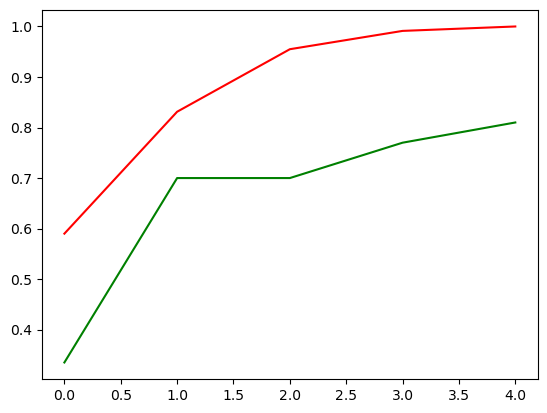

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],c='red')
plt.plot(history.history['val_accuracy'],c='green')
plt.show()

In [22]:
A1 = pd.read_csv("rest_reviews_testing.csv")
A1.head()

,Review
0,Tasty and delicious
1,crust is hard
2,yummy....I like Dominos pizza
3,fast service and good taste
4,Good taste


In [24]:
q_test=[]
for i in A1.Review:
    cleaned=i.lower()
    cleaned=re.sub("[^a-z ]","",cleaned)
    q_test.append(cleaned)
print(q_test)    

['tasty and delicious', 'crust is hard', 'yummyi like dominos pizza', 'fast service and good taste', 'good taste ', 'its very delicious hope it will maintain tast', 'food was okay but the cheesy dip provided was expired', 'taste is ok but not satisfied', 'poor service ', 'good hygiene food delivered by dominos with proper safety', 'not good', 'taste is not ok also service is not satisfied', 'delayed service', 'horrible taste', 'late service', 'taste is ok but delivery is too latecant spend that much time', 'disappointing food experience']


In [25]:
data_pred=cv.transform(q_test).toarray()
print(data_pred)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [26]:
T=[]
for i in nn.predict(data_pred):
    if round(i[0],2)>0.5:
        T.append(1)
    else:
        T.append(0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


In [27]:
A1["Liked"]= T


In [33]:
A1

,Review,Liked
0,Tasty and delicious,1
1,crust is hard,0
2,yummy....I like Dominos pizza,1
3,fast service and good taste,1
4,Good taste,1
5,Its very delicious... hope it will maintain ta...,1
6,Food was okay but the cheesy dip provided was ...,0
7,taste is ok but not satisfied,0
8,Poor service,0
9,Good hygiene food delivered by dominos with pr...,1


In [34]:
nn.save('restaurant_sentiment.keras')

In [35]:
import pickle
with open('cv.pkl','wb') as file:
    pickle.dump(cv,file)